In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('titanic.csv')

In [3]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
# Fill missing age with the average age
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Fill missing embarked with 'S' (most common)
df['Embarked'].fillna('S', inplace=True)

#Draop cabin column(too many missing values)
df.drop('Cabin', axis=1, inplace=True)

# Check that missing values are fixed
df.isna().sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_16160\4246667143.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_16160\4246667143.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

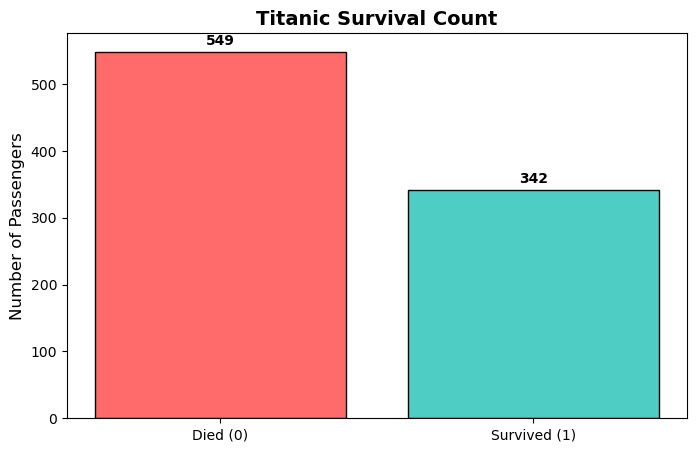

INSIGHT: More than 500 people died, while only about 340 survived.
This shows the sinking was a tragic event with more deaths than survivors.


In [6]:
#VISUALIZATION - Survival Count (How many survived vs died?)
plt.figure(figsize=(8,5))
survival_counts = df['Survived'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
labels = ['Died (0)', 'Survived (1)']
plt.bar(labels, survival_counts.values, color=colors, edgecolor='black')
plt.title('Titanic Survival Count', fontsize=14, fontweight='bold')
plt.ylabel('Number of Passengers', fontsize=12)
for i, v in enumerate(survival_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.show()

# INSIGHT 1:
print("INSIGHT: More than 500 people died, while only about 340 survived.")
print("This shows the sinking was a tragic event with more deaths than survivors.")

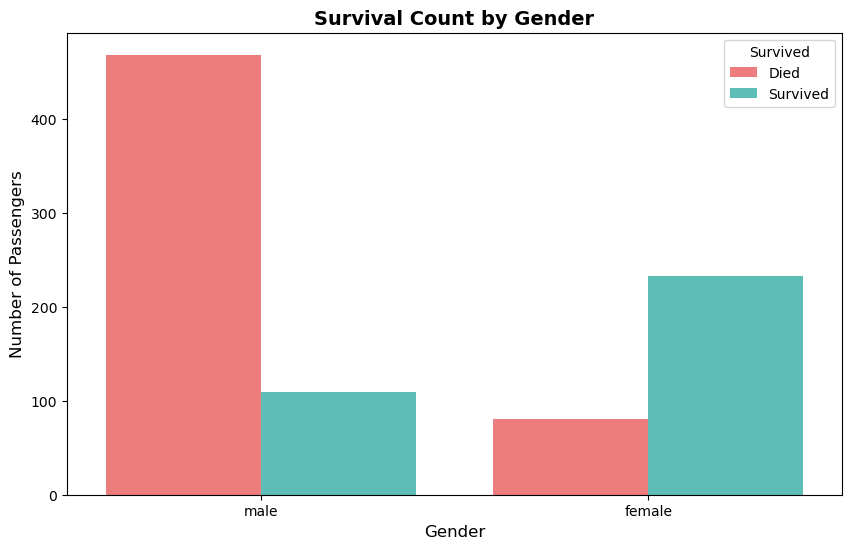

Female survival rate: 74.2%
Male survival rate: 18.9%
INSIGHT: Women had a much higher chance of survival (about 74%)
compared to men (only about 19%). This shows 'women and children first'
was followed during the evacuation.


In [7]:
# VISUALIZATION - Survival by Gender (Who survived more?)
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Sex', hue='Survived', palette=['#ff6b6b', '#4ecdc4'])
plt.title('Survival Count by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.legend(title='Survived', labels=['Died', 'Survived'])
plt.show()

# Calculate percentages
female_survival = df[df['Sex']=='female']['Survived'].mean() * 100
male_survival = df[df['Sex']=='male']['Survived'].mean() * 100
print(f"Female survival rate: {female_survival:.1f}%")
print(f"Male survival rate: {male_survival:.1f}%")

# INSIGHT 2:
print("INSIGHT: Women had a much higher chance of survival (about 74%)")
print("compared to men (only about 19%). This shows 'women and children first'")
print("was followed during the evacuation.")

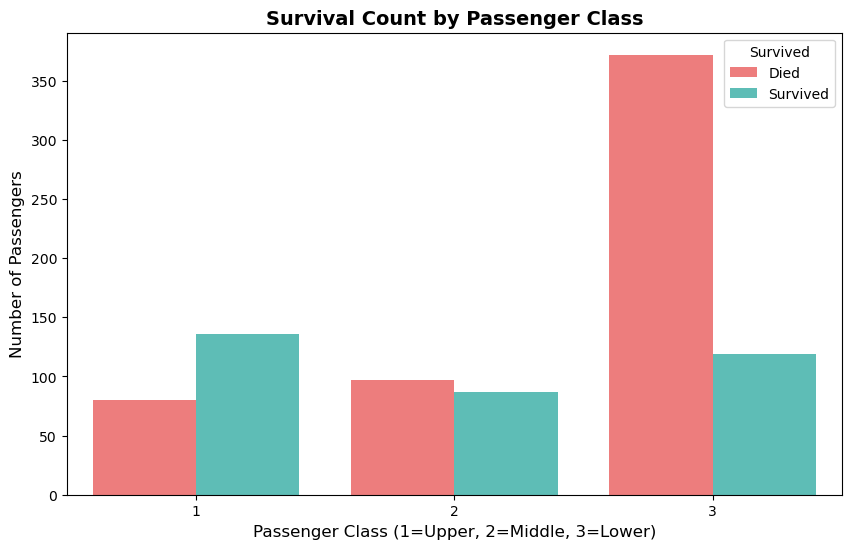

1st Class survival rate: 63.0%
2nd Class survival rate: 47.3%
3rd Class survival rate: 24.2%
INSIGHT: Wealthier passengers had a better chance of survival.
1st class had about 63% survival, while 3rd class only had about 24%.
This suggests social class played a role in who got lifeboats.


In [8]:
#VISUALIZATION - Survival by Passenger Class
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Pclass', hue='Survived', palette=['#ff6b6b', '#4ecdc4'])
plt.title('Survival Count by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class (1=Upper, 2=Middle, 3=Lower)', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.legend(title='Survived', labels=['Died', 'Survived'])
plt.show()

# Calculate survival rates by class
class1_survival = df[df['Pclass']==1]['Survived'].mean() * 100
class2_survival = df[df['Pclass']==2]['Survived'].mean() * 100
class3_survival = df[df['Pclass']==3]['Survived'].mean() * 100
print(f"1st Class survival rate: {class1_survival:.1f}%")
print(f"2nd Class survival rate: {class2_survival:.1f}%")
print(f"3rd Class survival rate: {class3_survival:.1f}%")

# INSIGHT 3:
print("INSIGHT: Wealthier passengers had a better chance of survival.")
print("1st class had about 63% survival, while 3rd class only had about 24%.")
print("This suggests social class played a role in who got lifeboats.")